<a href="https://colab.research.google.com/github/Irfansyah001/Machine-Learning-Project-Study/blob/main/223_prak6_DatasetBebas_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Memuat Dataset
Pada tahap pertama ini, kita mengunduh dan memuat dataset konsumsi energi menggunakan pustaka `kagglehub`. Dataset ini akan disimpan ke dalam sebuah DataFrame pandas untuk memudahkan pengolahan selanjutnya.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "test_energy_data.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "govindaramsriram/energy-consumption-dataset-linear-regression",
  file_path,
)

display(df.head())

/tmp/ipykernel_7313/3379938018.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 4.48k/4.48k [00:00<00:00, 8.30MB/s]


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


### Exploratory Data Analysis (EDA)
Mari kita lihat struktur kolom dari dataset ini beserta tipe datanya (apakah angka, teks, atau kategori).

In [ ]:
# Menampilkan informasi umum mengenai dataset (nama kolom, jumlah data tidak kosong, tipe data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


Selanjutnya, kita melihat statistik deskriptif dasar dari dataset kita. Ini membantu kita memahami rentang nilai (minimum, maksimum), rata-rata, serta sebaran data pada setiap kolom numerik.

In [ ]:
# Menampilkan statistik deskriptif dasar untuk melihat rentang nilai (min, max, rata-rata)
display(df.describe(include='all'))

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
count,100,100.000000,100.000000,100.000000,100.000000,100,100.00000
unique,3,NaN,NaN,NaN,NaN,2,NaN
top,Residential,NaN,NaN,NaN,NaN,Weekend,NaN
freq,40,NaN,NaN,NaN,NaN,56,NaN
mean,NaN,25881.920000,47.230000,26.970000,22.043300,NaN,4187.57830
std,NaN,13711.075264,29.905526,14.237846,6.957951,NaN,832.55985
min,NaN,1161.000000,2.000000,1.000000,10.400000,NaN,2351.97000
25%,NaN,14161.000000,21.000000,16.750000,15.682500,NaN,3621.92500
50%,NaN,27582.500000,47.000000,27.500000,21.970000,NaN,4249.39000
75%,NaN,38109.500000,73.000000,39.250000,27.492500,NaN,4797.17500


### 2. Visualisasi Data (Distribusi Target)
Kita membuat histogram untuk melihat distribusi nilai target yang ingin diprediksi, yaitu `Energy Consumption`. Selain itu, kita juga mengecek nilai skewness (kemiringan) untuk memastikan apakah datanya terdistribusi normal atau memerlukan transformasi matematis.

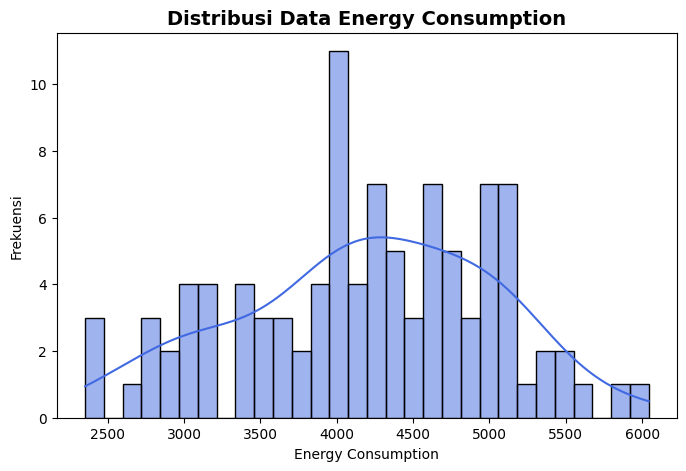

Nilai Skewness (Kemiringan):  -0.242142557275254


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Energy Consumption'], kde=True, bins=30, color='royalblue')
plt.title('Distribusi Data Energy Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Energy Consumption')
plt.ylabel('Frekuensi')
plt.show()

print("Nilai Skewness (Kemiringan): ", df['Energy Consumption'].skew())

### 3. Analisis Korelasi
Melalui Heatmap korelasi ini, kita dapat melihat hubungan antar variabel. Nilai yang mendekati 1 atau -1 menunjukkan korelasi yang kuat. Di sini kita memilah fitur mana yang paling berpengaruh terhadap konsumsi energi (misalnya `Square Footage`).

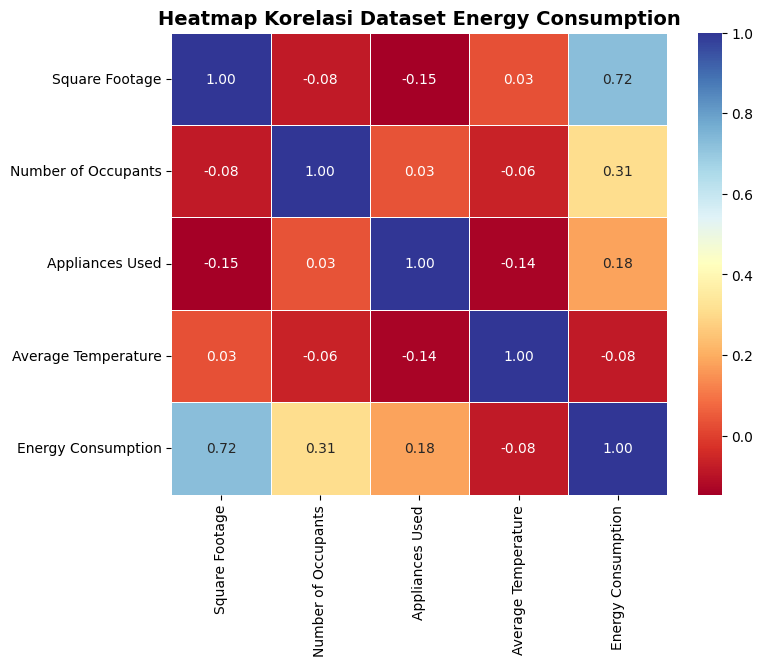

Energy Consumption     1.000000
Square Footage         0.724039
Number of Occupants    0.308594
Appliances Used        0.176380
Average Temperature   -0.079733
Name: Energy Consumption, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
# Tambahkan numeric_only=True agar hanya menghitung kolom angka
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Dataset Energy Consumption', fontsize=14, fontweight='bold')
plt.show()

print(correlation_matrix['Energy Consumption'].sort_values(ascending=False))

### 4. Data Splitting (Pembagian Data)
Sebelum melatih model, kita harus memisahkan data menjadi **Fitur (X)** dan **Target (y)**. Kolom teks yang tidak bisa diproses oleh Linear Regression sederhana dibuang. Kemudian, kita membaginya menjadi 80% data untuk *training* (belajar) dan 20% data untuk *testing* (ujian).

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
# Kita juga membuang kolom teks ('Building Type' dan 'Day of Week') agar bisa masuk ke model Linear Regression sederhana
X = df.drop(columns=['Energy Consumption', 'Building Type', 'Day of Week'])
y = df['Energy Consumption']

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total data pelatihan: {X_train.shape[0]} baris")
print(f"Total data pengujian: {X_test.shape[0]} baris")

Total data pelatihan: 80 baris
Total data pengujian: 20 baris


### 5. Membangun Model Linear Regression
Kita menginisialisasi model **Linear Regression**, kemudian menyuruh model tersebut belajar pola dari data *training* (`fit`). Setelah belajar, model melakukan prediksi pada data *testing* yang belum pernah dilihat sebelumnya (`predict`).

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("Proses training dan inferensi selesai!")

Proses training dan inferensi selesai!


### 6. Evaluasi Model Linear Regression
Untuk menilai seberapa pintar model kita, kita menghitung metrik eror seperti MAE dan RMSE, serta skor R-squared (R2). Grafik scatter plot digunakan untuk membandingkan secara visual seberapa dekat tebakan model (titik biru) dengan nilai aslinya (garis merah).

Mean Absolute Error (MAE): 409.15
Root Mean Squared Error (RMSE): 448.44
R-squared (R2) Score: 0.70


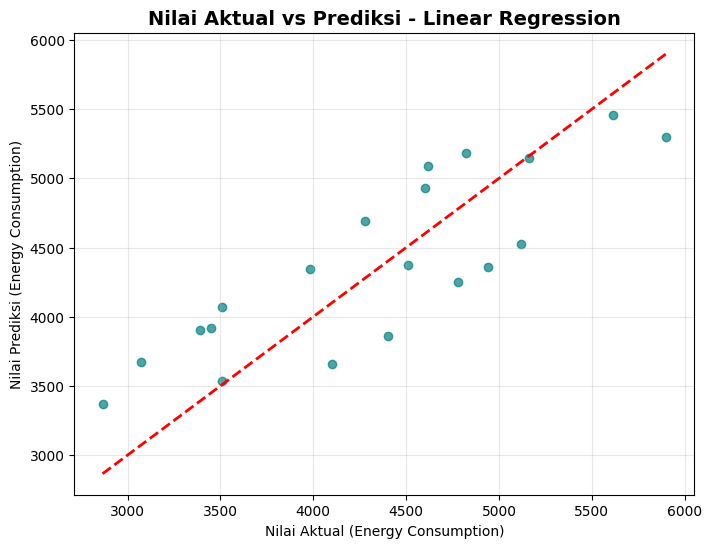

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')

# Garis merah menunjukkan prediksi sempurna (Aktual = Prediksi)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Nilai Aktual vs Prediksi - Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Aktual (Energy Consumption)')
plt.ylabel('Nilai Prediksi (Energy Consumption)')
plt.grid(True, alpha=0.3)
plt.show()

### 7. Membangun Model Random Forest
Sebagai perbandingan, kita membangun model **Random Forest Regressor** dengan menggunakan 100 pohon keputusan. Model ini akan dilatih menggunakan data yang sama untuk melihat apakah algoritma yang lebih kompleks ini bisa memberikan hasil yang lebih baik.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# model Random Forest
# n_estimators=100, menggunakan 100 'pohon' keputusan

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Training Process
model_rf.fit(X_train, y_train)

# Melakukan prediksi dari data pengujian
y_pred_rf = model_rf.predict(X_test)

print("Proses training Random Forest selesai!")

Proses training Random Forest selesai!


### 8. Evaluasi Model Random Forest
Tahap terakhir adalah mengevaluasi performa prediksi dari model Random Forest dan membandingkan hasil MAE, RMSE, serta R2 Score-nya dengan Linear Regression sebelumnya.

=== HASIL EVALUASI RANDOM FOREST ===
Mean Absolute Error (MAE): 456.95
Root Mean Squared Error (RMSE): 515.40
R-squared (R2) Score: 0.60



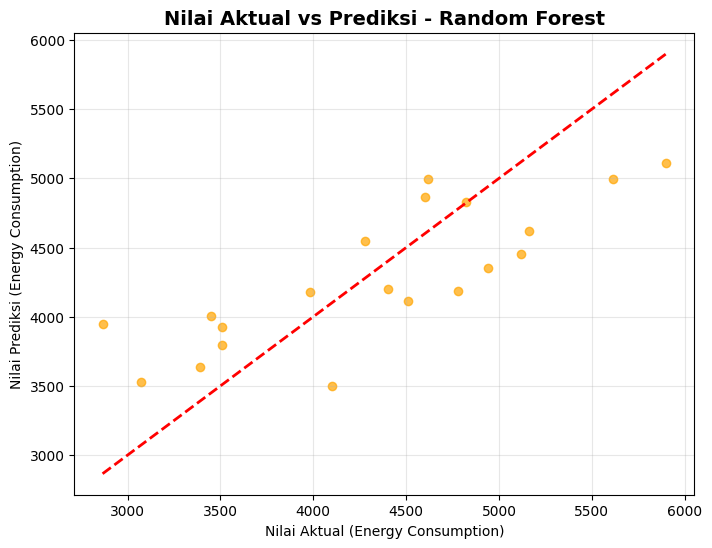

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== HASIL EVALUASI RANDOM FOREST ===")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2) Score: {r2_rf:.2f}\n")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='orange')

# Garis merah menunjukkan prediksi sempurna
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Nilai Aktual vs Prediksi - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Aktual (Energy Consumption)')
plt.ylabel('Nilai Prediksi (Energy Consumption)')
plt.grid(True, alpha=0.3)
plt.show()

### 9. Perbandingan Performa Model
Setelah melatih dan mengevaluasi kedua model, kita akan menggabungkan hasil metriknya ke dalam sebuah tabel dan membuat grafik batang. Hal ini memudahkan kita untuk melihat secara langsung model mana yang memiliki tingkat eror (MAE, RMSE) paling rendah dan skor akurasi ($R^2$) paling tinggi.

,Metrik,Linear Regression,Random Forest
0,MAE (Lebih rendah lebih baik),409.153229,456.950800
1,RMSE (Lebih rendah lebih baik),448.437630,515.395456
2,R-Squared (Lebih tinggi lebih baik),0.698493,0.601733


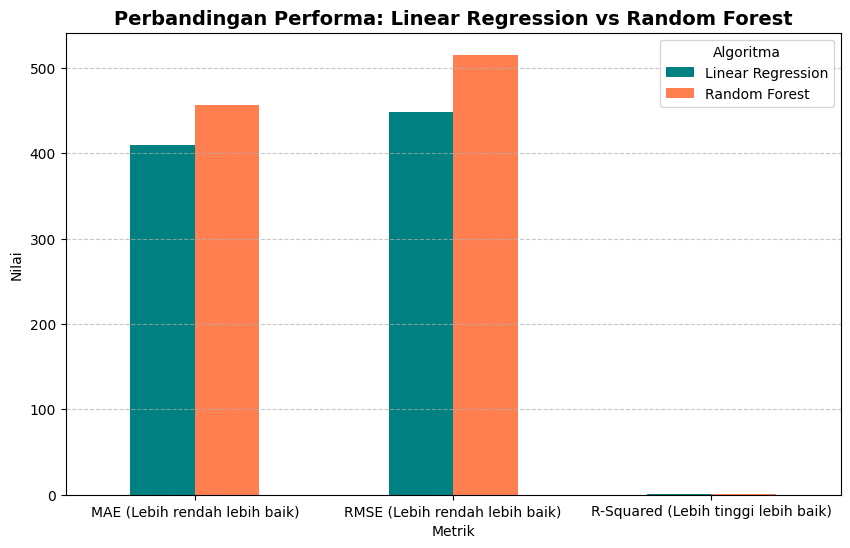

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Metrik': ['MAE (Lebih rendah lebih baik)', 'RMSE (Lebih rendah lebih baik)', 'R-Squared (Lebih tinggi lebih baik)'],
    'Linear Regression': [mae, rmse, r2],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
})

display(comparison_df)

comparison_df.set_index('Metrik').plot(kind='bar', figsize=(10, 6), color=['teal', 'coral'])
plt.title('Perbandingan Performa: Linear Regression vs Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Nilai')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Algoritma')
plt.show()

### 10. Analisis Visual Sebaran Prediksi
Untuk melengkapi angka-angka evaluasi di atas, kita juga membuat visualisasi sebaran (scatter plot) yang membandingkan hasil prediksi kedua model terhadap garis ideal (aktual = prediksi) secara berdampingan. Semakin rapat titik-titik tebakan dengan garis putus-putus merah, maka semakin akurat model tersebut.

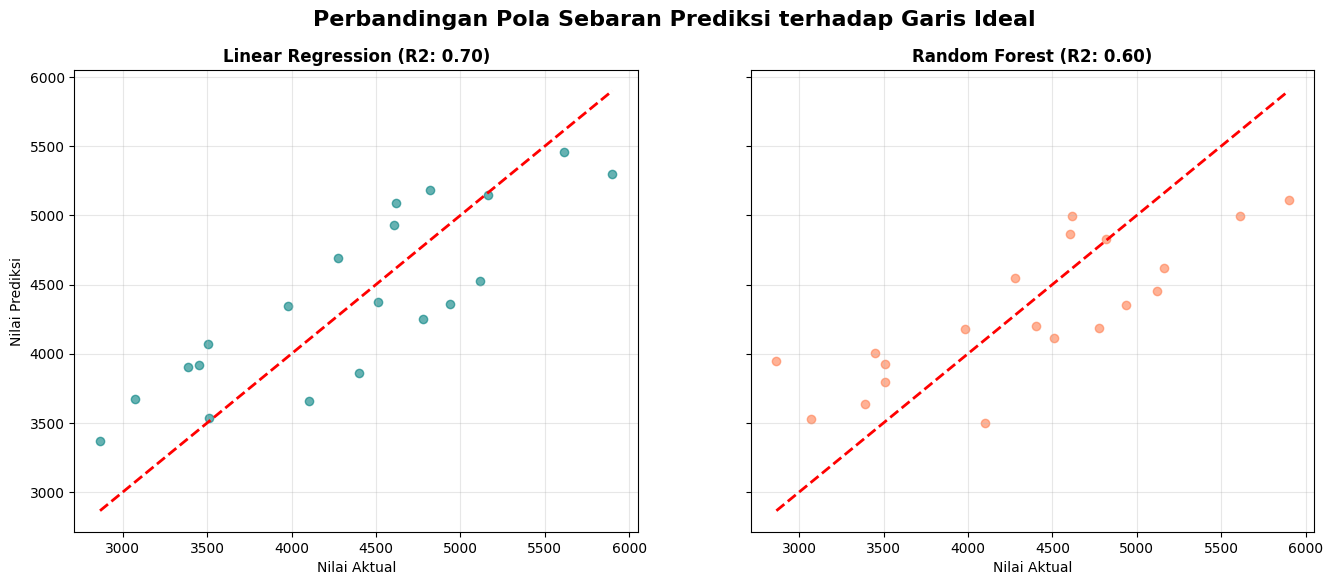

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].scatter(y_test, y_pred, alpha=0.6, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R2: {r2:.2f})', fontweight='bold')
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest (R2: {r2_rf:.2f})', fontweight='bold')
axes[1].set_xlabel('Nilai Aktual')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Pola Sebaran Prediksi terhadap Garis Ideal', fontsize=16, fontweight='bold')
plt.show()

### Kesimpulan Akhir
Berdasarkan hasil perbandingan metrik evaluasi dan visualisasi di atas, kita dapat menyimpulkan bahwa **Linear Regression** memberikan performa yang lebih baik dibandingkan Random Forest pada dataset ini.

Hal ini dibuktikan oleh nilai eror (MAE dan RMSE) Linear Regression yang lebih rendah serta skor $R^2$ yang lebih tinggi (0.70 vs 0.60). Mengingat dataset kita relatif kecil (100 baris) dan memiliki hubungan linear yang cukup kuat antara fitur (terutama `Square Footage`) dengan target (`Energy Consumption`), model Linear Regression yang sederhana terbukti lebih efisien dan lebih cocok dibandingkan model ansambel yang kompleks seperti Random Forest.